# Evaluating various extractions of Boreal AGB results

extracted using `code/maap_tools/notebooks/Extract_TCC_from_points_AWS.ipynb`

In [31]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

#### ESA Worldcover v1 2020
Manual: https://worldcover2020.esa.int/data/docs/WorldCover_PUM_V1.1.pdf ; pg 13

In [12]:
esawc2020_palette = {0:"#ffffff", 10:"#006400", 20:"#ffbb22", 30:"#ffff4c", 40:"#f096ff", 50:"#fa0000", 60:"#b4b4b4", 70:"#f0f0f0", 80:"#0064c8", 90:"#0096a0", 95:"#00cf75", 100:"#fae6a0"}
esawc2020_names =   {0:"NoData", 10:"Trees", 20:"Shrubs", 30:"Grass", 40:"Crops", 50:"Built-up", 60:"Barren / Sparse", 70:"Snow / Ice", 80:"Water", 90:"Herb. wetland", 95:"Mangroves", 100:"Moss / Lichen"}

In [4]:
liang_gdf_20250102 = gpd.read_file('/projects/my-public-bucket/databank/extract_from_points/liang_plots_high_latitude_additional_s3_20250102.gpkg')

In [5]:
liang_gdf_20250102.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 10646 entries, 0 to 10645
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   index                 10645 non-null  float64 
 1   Data_ID               10645 non-null  float64 
 2   index1                10645 non-null  float64 
 3   value_esawc2020       10646 non-null  int64   
 4   value_standage2020    3629 non-null   float64 
 5   value_agb_H30_2020    9878 non-null   float64 
 6   value_agb_S1H30_2020  9846 non-null   float64 
 7   geometry              10646 non-null  geometry
dtypes: float64(6), geometry(1), int64(1)
memory usage: 665.5 KB


In [6]:
liang_gdf_20250102.shape

(10646, 8)

In [7]:
liang_gdf_20250102.drop_duplicates(['geometry']).shape

(7959, 8)

In [8]:
from plotnine import *

In [9]:
liang_gdf_20250102.cx[-56.11232:-56.11230, 49.23499:49.23500].drop_duplicates(['geometry'])

,index,Data_ID,index1,value_esawc2020,value_standage2020,value_agb_H30_2020,value_agb_S1H30_2020,geometry
8384,8384.0,8385.0,8384.0,50,50.0,28.945303,25.388264,POINT (-56.11231 49.23500)


/opt/conda/envs/python/lib/python3.10/site-packages/pandas/plotting/_matplotlib/tools.py:327: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
/opt/conda/envs/python/lib/python3.10/site-packages/pandas/plotting/_matplotlib/tools.py:327: UserWarning: Data has no positive values, and therefore cannot be log-scaled.


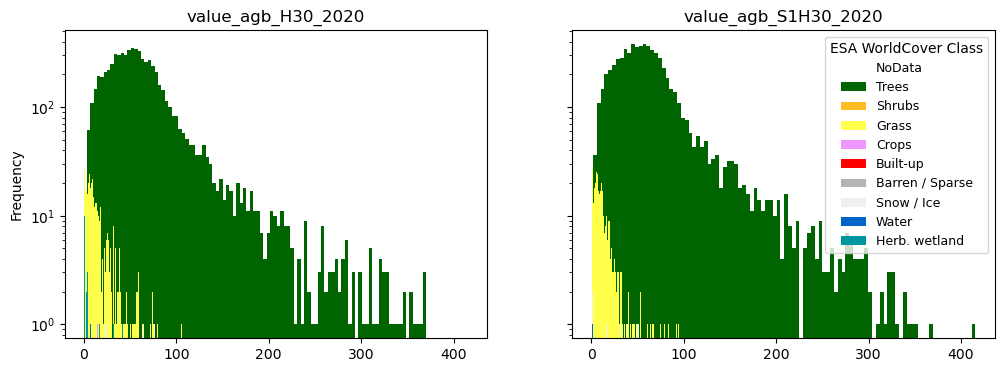

In [55]:
fig, axes = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(12,4))

pivot_df_1 = liang_gdf_20250102.drop_duplicates(['geometry']).pivot(columns="value_esawc2020", values="value_agb_H30_2020")
pivot_df_2 = liang_gdf_20250102.drop_duplicates(['geometry']).pivot(columns="value_esawc2020", values="value_agb_S1H30_2020")

for i, category in enumerate(pivot_df.columns):
    pivot_df_1[category].plot(ax = axes[0], kind='hist', color=list(esawc2020_palette.values())[i], alpha=1, label=list(esawc2020_names.values())[i], bins=100, log=True)
    axes[0].set_title('value_agb_H30_2020', fontsize=12)
    pivot_df_2[category].plot(ax = axes[1], kind='hist', color=list(esawc2020_palette.values())[i], alpha=1, label=list(esawc2020_names.values())[i], bins=100, log=True)
    axes[1].set_title('value_agb_S1H30_2020', fontsize=12)

plt.legend(title="ESA WorldCover Class", fontsize=9)
plt.show()

### An extraction prior to Version 2

In [37]:
liang_gdf_20250102['cat_esawc2020'] = liang_gdf_20250102.value_esawc2020.astype('category')

In [40]:
liang_gdf_20250102.dropna().explore(column='cat_esawc2020', cmap=list(esawc2020_palette.values()), tiles='https://services.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}', attr=' ')

### Compare `AGB_H30_2020` and `AGB_S1H30_2020`

/tmp/ipykernel_2002/4138521580.py:15: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.


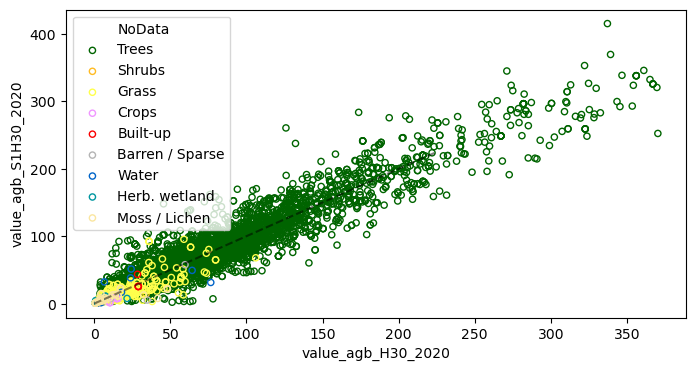

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))

for lc_value, data in liang_gdf_20250102.groupby('value_esawc2020'):

    # Define the color for each group using the dictionary
    lc_color = esawc2020_palette[lc_value]
    lc_label = esawc2020_names[lc_value]

    # Plot each group using the color defined above
    data.plot.scatter(ax=ax, x='value_agb_H30_2020', y='value_agb_S1H30_2020', label=lc_label, 
                      #s='value_tcc2020', 
                      marker='o', fc='none' , ec=lc_color)

#ax.legend(bbox_to_anchor=(1.0, .5), prop={'size': 12})
ax.plot((0,225), (0,225), 'k-', alpha=0.5, zorder=1, linestyle='--')

In [46]:
liang_gdf_20250102['diff_v2_prior'] = liang_gdf_20250102.value_agb_S1H30_2020 - liang_gdf_20250102.value_agb_H30_2020
liang_gdf_20250102.dropna().explore(column='diff_v2_prior', vmin=-25, vmax=25, cmap='RdBu',  tiles='https://services.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}', attr=' ')